In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
import numpy as np

In [2]:
(Xtrain, ytrain), (Xtest, ytest)= mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [19]:
type(Xtrain)

numpy.ndarray

In [3]:
Xtrain=Xtrain/255.0
Xtest=Xtest/255.0

In [4]:
Xtrain.shape

(60000, 28, 28)

In [39]:
modelo=models.Sequential([
    layers.Conv2D(32, (3,3), padding='same', activation="relu", input_shape=(28,28,1)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(3,3)),
    layers.Dropout(0.5),
    
    layers.Flatten(),
    layers.Dense(10, activation="softmax")
])

In [40]:
modelo.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 9, 9, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 9, 9, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 2592)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │        25,930 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,378 (103.04 KB)

 Trainable params: 26,314 (102.79 KB)

 Non-trainable params: 64 (256.00 B)

In [41]:
modelo.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=['accuracy'])

In [42]:
hist = modelo.fit(Xtrain, ytrain, epochs=20, batch_size=32, validation_split=0.2)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 26s 16ms/step - accuracy: 0.9181 - loss: 0.2688 - val_accuracy: 0.9703 - val_loss: 0.0978
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.9632 - loss: 0.1169 - val_accuracy: 0.9763 - val_loss: 0.0750
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.9690 - loss: 0.0998 - val_accuracy: 0.9823 - val_loss: 0.0603
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.9711 - loss: 0.0907 - val_accuracy: 0.9828 - val_loss: 0.0583
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.9725 - loss: 0.0869 - val_accuracy: 0.9793 - val_loss: 0.0732
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.9750 - loss: 0.0801 - val_accuracy: 0.9827 - val_loss: 0.0610
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.9749 - loss: 0.0773 - val_accuracy: 0.9852 - val_loss: 0.0536
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 23s 16ms/step - accuracy: 0.9761 -

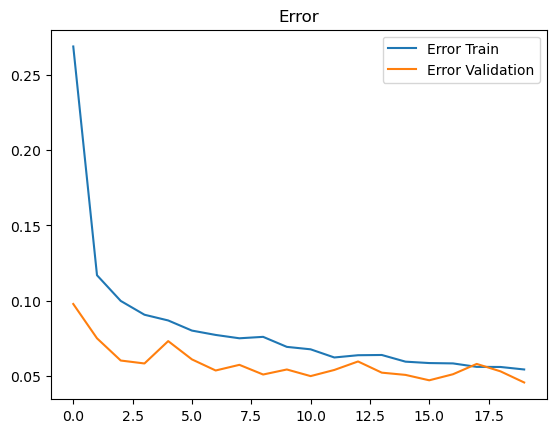

In [43]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(hist.history['loss'], label='Error Train')
plt.plot(hist.history['val_loss'], label='Error Validation')
plt.title("Error")
plt.legend()

In [86]:
modelo2=models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    layers.Flatten(),
    
    layers.Dense(64, activation='relu'),
    
    layers.Dense(10, activation='softmax')
])

In [87]:
modelo2.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=['accuracy'])

In [88]:
hist2 = modelo2.fit(Xtrain, ytrain, epochs=5, batch_size=32, validation_split=0.2)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.9455 - loss: 0.1772 - val_accuracy: 0.9818 - val_loss: 0.0593
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.9810 - loss: 0.0614 - val_accuracy: 0.9876 - val_loss: 0.0426
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.9860 - loss: 0.0446 - val_accuracy: 0.9898 - val_loss: 0.0351
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.9882 - loss: 0.0359 - val_accuracy: 0.9856 - val_loss: 0.0473
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - accuracy: 0.9907 - loss: 0.0281 - val_accuracy: 0.9907 - val_loss: 0.0326


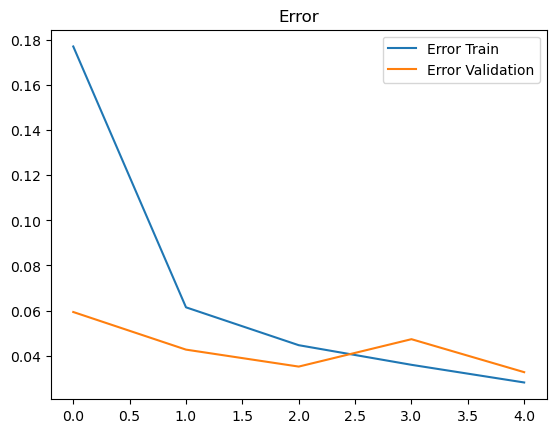

In [89]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(hist2.history['loss'], label='Error Train')
plt.plot(hist2.history['val_loss'], label='Error Validation')
plt.title("Error")
plt.legend()

In [90]:
modelo2.save('CNN_edad.keras')